In [68]:
!pip install lightgbm

In [69]:
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, root_mean_squared_error, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Load the parquet file
file_path = 'features/ml_features_1m_v2.parquet'
df = pd.read_parquet(file_path)

print(df[df["trade_count"] != 0])

# Display the first few rows to verify
df.head()

                                                 market_id  \
35       0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...   
59       0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...   
80       0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...   
82       0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...   
92       0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...   
...                                                    ...   
5587300  0xfff145c6201796960cac69aea3f608a1cc3d497eb7ca...   
5587301  0xfff145c6201796960cac69aea3f608a1cc3d497eb7ca...   
5587327  0xfff145c6201796960cac69aea3f608a1cc3d497eb7ca...   
5587341  0xfff145c6201796960cac69aea3f608a1cc3d497eb7ca...   
5587416  0xfff145c6201796960cac69aea3f608a1cc3d497eb7ca...   

                       minute_bar  close_mid  mean_spread  close_spread  \
35      2026-03-06 00:35:00+00:00     0.2700     0.480000         0.480   
59      2026-03-06 00:59:00+00:00     0.4000     0.269412         0.260   
80      2026-03-06 02:02:00+00

,market_id,minute_bar,close_mid,mean_spread,close_spread,bar_volatility,total_volume,buy_volume,sell_volume,trade_count,order_flow_imbalance,target,return_1m,bid_depth,ask_depth,depth_imbalance
0,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 00:00:00+00:00,0.285,0.453750,0.45,0.005,0.0,0.0,0.0,0,0.0,0,0.017857,287.79,3845.07,-0.860731
1,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 00:01:00+00:00,0.285,0.450000,0.45,0.000,0.0,0.0,0.0,0,0.0,0,0.000000,287.79,3845.07,-0.860731
2,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 00:02:00+00:00,0.290,0.443333,0.44,0.005,0.0,0.0,0.0,0,0.0,0,0.017544,287.79,3845.07,-0.860731
3,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 00:03:00+00:00,0.290,0.440000,0.44,0.000,0.0,0.0,0.0,0,0.0,0,0.000000,287.79,3845.07,-0.860731
4,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 00:04:00+00:00,0.290,0.440000,0.44,0.000,0.0,0.0,0.0,0,0.0,0,0.000000,366.80,8838.88,-0.920310


In [70]:
# Convert minute_bar to datetime and sort to ensure chronological order
df['minute_bar'] = pd.to_datetime(df['minute_bar'])
df = df.sort_values('minute_bar')

#df = df[~df["trade_count"] == 0]

# Imputar valores nulos com 0 para evitar erros nos modelos do Scikit-Learn
df = df.fillna(0)

# Define features (X) and target (y)
# Drop IDs, timestamps, and target-related columns from the feature set
drop_columns = ['market_id', 'minute_bar', 'target']
X = df.drop(columns=drop_columns)
y = df['target'] 

# Perform a chronological split (e.g., first 80% for training, last 20% for testing)
split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (4470037, 13)
Testing data shape: (1117510, 13)


In [71]:
results_list = []

# Initialize the LightGBM model
model_lgb = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

# Train the model with early stopping
model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# Make predictions on the test set
predictions = model_lgb.predict(X_test)
probabilities = model_lgb.predict_proba(X_test)[:, 1]

# Evaluate the model
acc = accuracy_score(y_test, predictions)
prec = precision_score(y_test, predictions, zero_division=0)
rec = recall_score(y_test, predictions, zero_division=0)
f1 = f1_score(y_test, predictions, zero_division=0)
roc = roc_auc_score(y_test, probabilities)

print(f"\nAccuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc:.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, predictions)}")

results_list.append({
    'Model': 'LightGBM',
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1-Score': f1,
    'ROC-AUC': roc
})

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[102]	valid_0's binary_logloss: 0.301414

Accuracy: 0.8446
Precision: 0.8397
Recall: 0.4979
F1-Score: 0.6251
ROC-AUC: 0.9092

Confusion Matrix:
[[799144  27636]
 [145971 144759]]


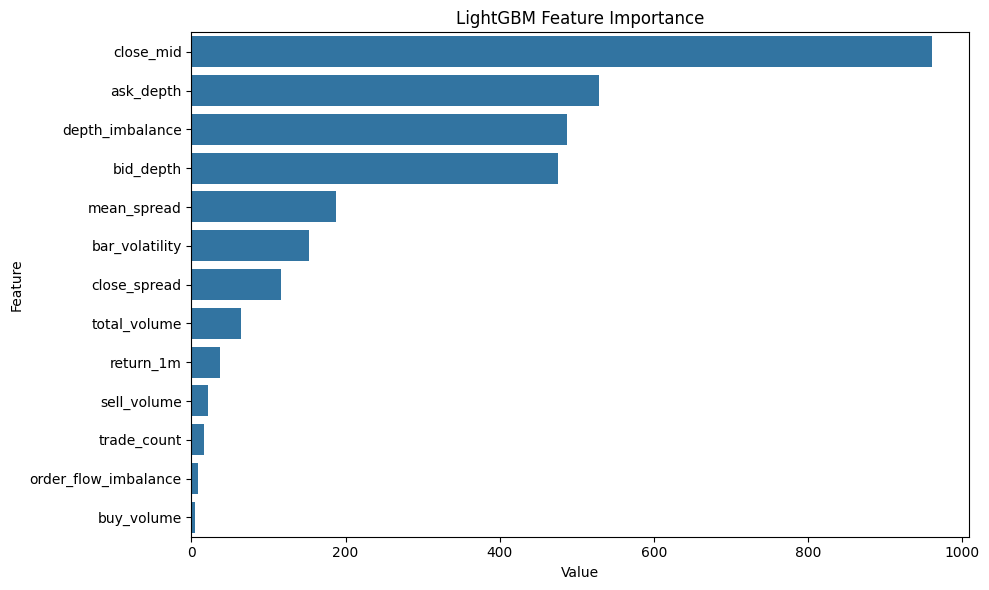

In [72]:
# Extract feature importances
feature_imp = pd.DataFrame({
    'Value': model_lgb.feature_importances_, 
    'Feature': X.columns
})

# Plot the top features
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Value", 
    y="Feature", 
    data=feature_imp.sort_values(by="Value", ascending=False)
)
plt.title('LightGBM Feature Importance')
plt.tight_layout()
plt.show()

# Análise de Importância das Variáveis (Feature Importance) - LightGBM

O gráfico gerado apresenta a **importância das features** (variáveis) calculada pelo modelo LightGBM. Esta métrica indica o quanto cada variável contribuiu para as decisões e divisões dentro das árvores do modelo para chegar na previsão final (geralmente medido pelo número de vezes que a variável foi usada para dividir os dados, conhecido como *split*, ou pelo ganho total na redução do erro, conhecido como *gain*).

Aqui está a interpretação detalhada dos seus resultados com base no gráfico gerado:

## 1. As Variáveis Mais Importantes (Os "Motores" do Modelo)
Estas são as variáveis que o modelo considerou mais úteis para prever o seu `target`.
* **`close_mid`**: É, de longe, a variável com maior dominância (com valor superando 800). O preço médio (mid-price) no fechamento do *minute bar* contém o maior poder preditivo do modelo atual. 
* **Variáveis de Livro de Ofertas (`depth_imbalance`, `bid_depth`, `ask_depth`)**: Formam o segundo bloco mais importante (valores entre 400 e 600). O modelo está extraindo um sinal forte da liquidez do mercado (profundidade das ofertas de compra e venda) e, principalmente, do desequilíbrio entre essas pontas. Isso indica que a dinâmica da microestrutura do livro de ofertas é essencial para a sua previsão.

## 2. Variáveis de Importância Moderada
* **`mean_spread` e `close_spread`**: As métricas de *spread* (a diferença entre o melhor preço de compra e venda) mostraram uma importância moderada (valores em torno de 200). Elas ajudam a refinar as previsões, provavelmente servindo como indicativos secundários da volatilidade ou do custo de liquidez.

## 3. Variáveis de Baixa Importância ou Ignoradas
Estas variáveis tiveram pouco ou nenhum impacto nas previsões finais. O LightGBM praticamente as ignorou ao construir as árvores de decisão.
* **`bar_volatility`**: Teve uma contribuição muito marginal, quase próxima a zero.
* **Métricas de Volume e Fluxo (`total_volume`, `trade_count`, `sell_volume`, `buy_volume`, `order_flow_imbalance`)**: Possuem barras invisíveis (importância zero). Isso significa que, frente às variáveis de preço e profundidade do livro, o volume negociado e a contagem de trades não agregaram nenhum ganho de informação para prever o `target`.

---

## 💡 Recomendações e Próximos Passos
1. **Seleção de Variáveis (Feature Selection)**: Você pode tentar **remover** as variáveis com importância zero do seu arquivo `.parquet` e rodar o treinamento do LightGBM novamente. Um modelo com menos variáveis (apenas as que importam) é mais rápido para treinar, generaliza melhor para dados novos e tem menos risco de sofrer *overfitting*.
2. **Engenharia de Features (Feature Engineering)**: Como o modelo demonstrou depender muito das métricas de livro de ofertas (`depth_imbalance`, `close_mid`), o próximo passo natural para tentar melhorar o *Test RMSE* é criar novas variáveis derivadas destas. Por exemplo:
   * A variação do `depth_imbalance` em relação ao minuto anterior.
   * Médias móveis exponenciais do `close_mid` e dos *spreads*.

In [73]:
from sklearn.preprocessing import StandardScaler

# Padronizando os dados para a Regressão Logística
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_lr = LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1, class_weight="balanced")
model_lr.fit(X_train_scaled, y_train)

predictions_lr = model_lr.predict(X_test_scaled)
probabilities_lr = model_lr.predict_proba(X_test_scaled)[:, 1]

results_list.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, predictions_lr),
    'Precision': precision_score(y_test, predictions_lr, zero_division=0),
    'Recall': recall_score(y_test, predictions_lr, zero_division=0),
    'F1-Score': f1_score(y_test, predictions_lr, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, probabilities_lr)
})
print("Regressão Logística treinada e avaliada com sucesso!")

/home/gabriel/repos/github.com/GbAraujoSouza/contract-predict/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Regressão Logística treinada e avaliada com sucesso!


In [74]:
model_dt = DecisionTreeClassifier(max_depth=10, random_state=42)
model_dt.fit(X_train, y_train)

predictions_dt = model_dt.predict(X_test)
probabilities_dt = model_dt.predict_proba(X_test)[:, 1]

results_list.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, predictions_dt),
    'Precision': precision_score(y_test, predictions_dt, zero_division=0),
    'Recall': recall_score(y_test, predictions_dt, zero_division=0),
    'F1-Score': f1_score(y_test, predictions_dt, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, probabilities_dt)
})
print("Árvore de Decisão treinada e avaliada com sucesso!")

Árvore de Decisão treinada e avaliada com sucesso!


In [75]:
model_rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1, class_weight="balanced")
model_rf.fit(X_train, y_train)

predictions_rf = model_rf.predict(X_test)
probabilities_rf = model_rf.predict_proba(X_test)[:, 1]

results_list.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, predictions_rf),
    'Precision': precision_score(y_test, predictions_rf, zero_division=0),
    'Recall': recall_score(y_test, predictions_rf, zero_division=0),
    'F1-Score': f1_score(y_test, predictions_rf, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, probabilities_rf)
})
print("Random Forest treinado e avaliado com sucesso!")

Random Forest treinado e avaliado com sucesso!


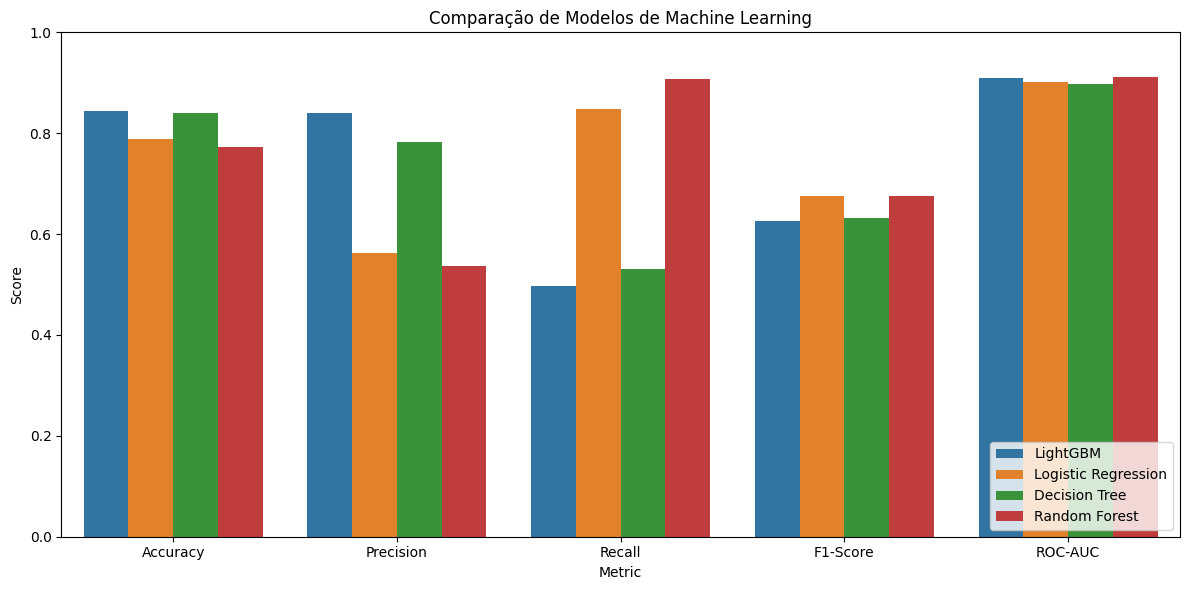

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,Random Forest,0.772201,0.536752,0.908286,0.674757,0.910807
0,LightGBM,0.844648,0.839694,0.497916,0.625140,0.909215
1,Logistic Regression,0.789075,0.562831,0.847608,0.676470,0.901366
2,Decision Tree,0.839489,0.781664,0.531479,0.632739,0.897937


In [76]:
df_results = pd.DataFrame(results_list)

# Plot comparison
plt.figure(figsize=(12, 6))
df_melted = df_results.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(x="Metric", y="Score", hue="Model", data=df_melted)
plt.title("Comparação de Modelos de Machine Learning")
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Display sorted by ROC-AUC
df_results.sort_values(by="ROC-AUC", ascending=False)

# Validação com K-Fold e Dados Temporais

Abaixo aplicamos o `KFold` tradicional (5 partições) em todos os modelos avaliados e comparamos a média das métricas com o split cronológico simples feito anteriormente.

Iniciando K-Fold Cross Validation (5 splits) para todos os modelos...

Modelo: LightGBM
Treinando Fold 1...
Treinando Fold 2...
Treinando Fold 3...
Treinando Fold 4...
Treinando Fold 5...

Modelo: Logistic Regression
Treinando Fold 1...
Treinando Fold 2...
Treinando Fold 3...
Treinando Fold 4...
Treinando Fold 5...

Modelo: Decision Tree
Treinando Fold 1...
Treinando Fold 2...
Treinando Fold 3...
Treinando Fold 4...
Treinando Fold 5...

Modelo: Random Forest
Treinando Fold 1...
Treinando Fold 2...
Treinando Fold 3...
Treinando Fold 4...
Treinando Fold 5...


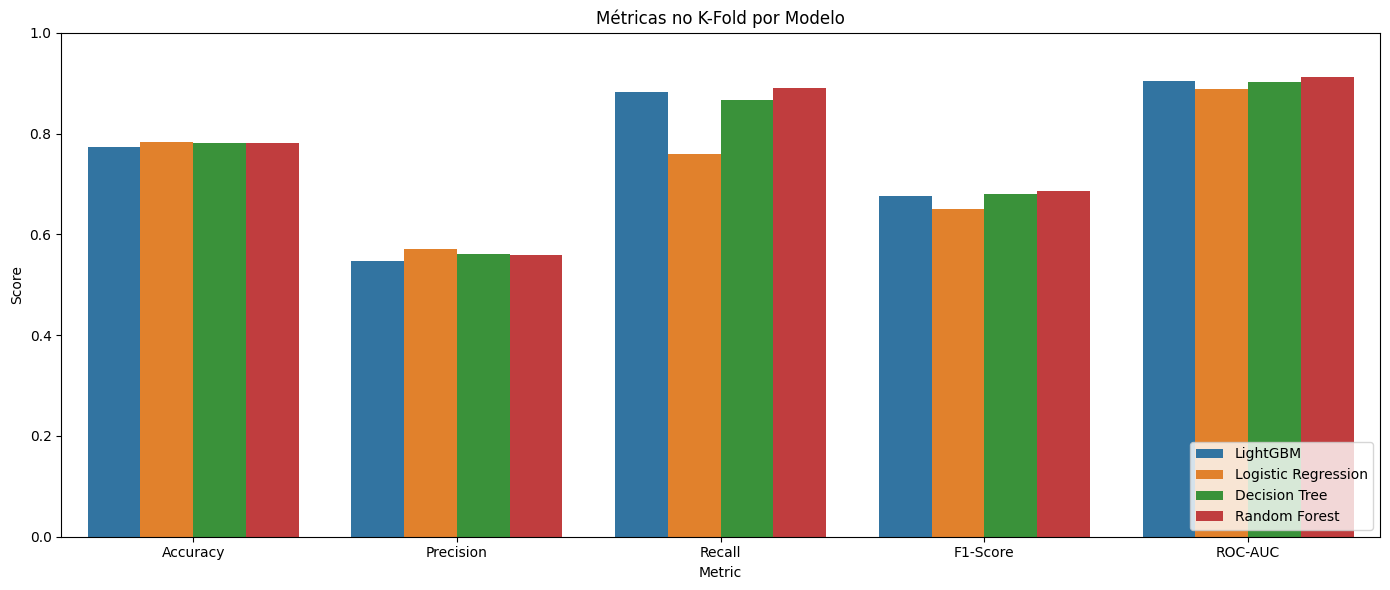

,Split Type,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Cronológico (80/20),LightGBM,0.844648,0.839694,0.497916,0.625140,0.909215
1,Cronológico (80/20),Logistic Regression,0.789075,0.562831,0.847608,0.676470,0.901366
2,Cronológico (80/20),Decision Tree,0.839489,0.781664,0.531479,0.632739,0.897937
3,Cronológico (80/20),Random Forest,0.772201,0.536752,0.908286,0.674757,0.910807
4,K-Fold (Média 5 Folds),LightGBM,0.773715,0.547477,0.881812,0.675307,0.904796
5,K-Fold (Média 5 Folds),Logistic Regression,0.782497,0.570497,0.760016,0.650637,0.888426
6,K-Fold (Média 5 Folds),Decision Tree,0.782203,0.560783,0.865791,0.680107,0.901446
7,K-Fold (Média 5 Folds),Random Forest,0.782317,0.558554,0.890808,0.686200,0.911490


In [78]:
from sklearn.model_selection import KFold
import numpy as np
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

print("Iniciando K-Fold Cross Validation (5 splits) para todos os modelos...")
kf = KFold(n_splits=5, shuffle=False)

models_cv = {
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
        class_weight="balanced"
    ),
    'Logistic Regression': make_pipeline(
        StandardScaler(),
        LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced")
    ),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42, class_weight="balanced"),
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1, class_weight="balanced")
}

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
kfold_summary = []

# Resetando index para iterar mais facilmente nos arrays do KFold
X_cv = X.reset_index(drop=True)
y_cv = y.reset_index(drop=True)

for model_name, model_template in models_cv.items():
    print(f"\nModelo: {model_name}")
    model_metrics = {metric: [] for metric in metrics}

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_cv), start=1):
        print(f"Treinando Fold {fold}...")
        X_tr, X_te = X_cv.iloc[train_idx], X_cv.iloc[test_idx]
        y_tr, y_te = y_cv.iloc[train_idx], y_cv.iloc[test_idx]

        model_cv = clone(model_template)
        model_cv.fit(X_tr, y_tr)

        preds = model_cv.predict(X_te)
        probs = model_cv.predict_proba(X_te)[:, 1]

        model_metrics['Accuracy'].append(accuracy_score(y_te, preds))
        model_metrics['Precision'].append(precision_score(y_te, preds, zero_division=0))
        model_metrics['Recall'].append(recall_score(y_te, preds, zero_division=0))
        model_metrics['F1-Score'].append(f1_score(y_te, preds, zero_division=0))
        model_metrics['ROC-AUC'].append(roc_auc_score(y_te, probs))

    kfold_avg = {metric: np.mean(values) for metric, values in model_metrics.items()}
    kfold_summary.append({'Split Type': 'K-Fold (Média 5 Folds)', 'Model': model_name, **kfold_avg})

df_kfold = pd.DataFrame(kfold_summary)
df_chronological = df_results.copy()
df_chronological['Split Type'] = 'Cronológico (80/20)'

df_comp = pd.concat([
    df_chronological[['Split Type', 'Model', *metrics]],
    df_kfold[['Split Type', 'Model', *metrics]]
], ignore_index=True)

df_comp_melted = df_comp.melt(id_vars=['Split Type', 'Model'], var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=df_comp_melted[df_comp_melted['Split Type'] == 'K-Fold (Média 5 Folds)'])
plt.title('Métricas no K-Fold por Modelo')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

df_comp